## Probability theory - exercises

This notebook contains exercises to test your understanding on the probability chapter of the course

-------------------------

To solve the problems in Python, you'll need to import the following libraries:

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import scipy

## Problem 1: unfair coins
We are given the task of studying a set of $n = 100$ equivalent unfair coins. 

We conduct a series of experiments, in which we toss all of our coins at once. We count how many heads we obtain each time, and obtain a value for the probability $prob(k)$ of obtaining $k$ heads across all of the experiments. The data are summarised in the file *unfair_coins_data.csv*, which you can import using the following line of code:

In [2]:
unfair_coins_data = np.loadtxt("probability_problems_files/unfair_coins_data.csv", delimiter=",", skiprows=1)
data_ks = unfair_coins_data[:, 0].astype(int)
data_ps = unfair_coins_data[:, 1]

**Q1**: Plot a histogram showing $p(k)$ as a function of $k$

In [9]:
#Your answer here

**Q2**: Calculate the average number of heads for this distribution

In [10]:
#Your answer here

**Q3**: What can you deduce from this value? If we look at coins individually, are they more likely to land on heads or tails?

In [11]:
#Your answer here

**Q4**: What is your estimate for $p$, the probability of obtaining tails in 1 toss?

In [12]:
#Your answer here

**Q5**: It's time to test this! Run the following cell and play around with the interactive distribution of $n=100$ coins. You can change the value of $p$, the probability of 1 coin falling on heads, to try to match the model to the data plotted in black. What value of $p$ gives the best fit to the data?

In [13]:
#Interactive simulation

n=100

def binom_pmf(k, p, n=100):
    """Binomial pmf for X ~ Bin(n, p)"""
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

def plot_binomial(p=0.5):
    ks = np.arange(0, n+1)
    probs = np.array([binom_pmf(k, p, n) for k in ks])

    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    # Background layer (your provided data)
    markerline, stemlines, baseline = ax.stem(
            data_ks, data_ps, basefmt=" "
        )
    plt.setp(markerline, alpha=0.8, color = 'black')
    plt.setp(stemlines, alpha=0.8, color = 'black')
    markerline.set_zorder(1)
    stemlines.set_zorder(1)

    # Moving interactive distribution
    ax.bar(ks, probs, alpha=0.35, zorder=2)

    # Highlight mean k=np (optional but nice)
    k_mean = int(round(n * p))
    ax.bar([k_mean], [binom_pmf(k_mean, p, n)], alpha=1.0, zorder=3)

    ax.set_xlim(-1, n+1)
    ax.set_xlabel("k")
    ax.set_ylabel("Probability mass")
    ax.set_title(f"Finding p(1 head) in unfair die")
    plt.tight_layout()
    plt.show()

interact(
    plot_binomial,
    p=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5, description="p (1 head)")
)

interactive(children=(FloatSlider(value=0.5, description='p (1 head)', max=0.99, min=0.01, step=0.01), Output(…

<function __main__.plot_binomial(p=0.5)>

## Problem 2: cars arriving at a crossing

Colour boredom has spread around the city of London, and only blue, yellow and grey cars are allowed to circulate. We want to study the arrival of cars at a zebra crossing as a Poissonian process. We start by conducting an experiment 2h long experiment, in which we count the number of cars of each type arriving at the crossing every minute. The data of this experiment can be imported from the file crossing_cars_data.csv using the following code snippet:

In [14]:
crossing_cars_data = np.loadtxt("probability_problems_files/crossing_cars_data.csv", delimiter=",", skiprows=1)
time = crossing_cars_data[:, 0].astype(int)
yellow_cars = crossing_cars_data[:, 1].astype(int)
blue_cars = crossing_cars_data[:, 2].astype(int)
grey_cars = crossing_cars_data[:, 3].astype(int)

**Q1**: Plot the number of cars of each type as a function of time. From the plot, estimate the following: 
- The car colour with the highest count per minute
- The car colour with the largest fluctuations in numbers
- The most likely number of cars for each type

In [15]:
#Your answer here

**Q2**: Transform the datasets into three probability distributions (empirical PMFs) by considering: 
$$
P(k)=\frac{\#\text{ minutes with count } k}{120}
$$


In [16]:
#Your answer here


**Q3**: Use the mean values you calculated in Q1 as an estimate for $\lambda$ and find the corresponding Poisson probability terms with: 
$$
P(k)=\frac{{\lambda}^{k}}{k!}·{e}^{-\lambda}
$$
Compare the Poissonian distributions with the empirical distributions from Q2 in a plot.


In [17]:
#Your answer here

## Problem 3: a 2D uniform distribution
We are going to study a 2D uniform distribution in the $(x,y)$ coordinates space

Consider a square dartboard of side length $l = 2$, like the one shown in the cell below:

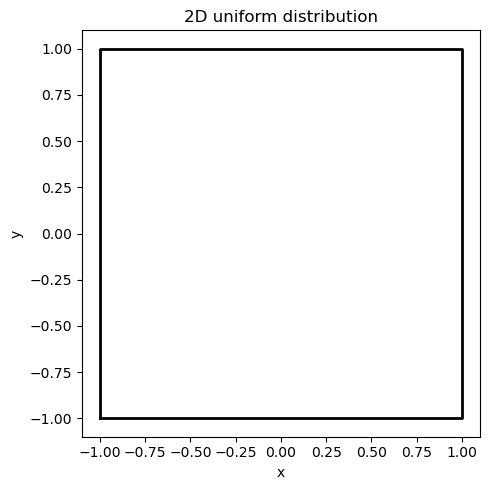

In [18]:
#Square plot
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]

plt.figure(figsize=(5, 5))
plt.plot(square_x, square_y, linewidth=2, label="Square", color='black')
plt.title("2D uniform distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**Q1**: Let's start by modelling the throw of $N = 10000$ dards that land on the board. Can you generate an uniform distribution of hits in $(x,y)$ using *np.random*?

In [19]:
#Your answer here

**Q2**: Represent the distribution of hits on the dardboard

In [21]:
#Your answer here

**Q3**: If we divide the dardboard into 4 equal squares, as shown below, what is the probability that a newly thrown dard hits the upper right one?

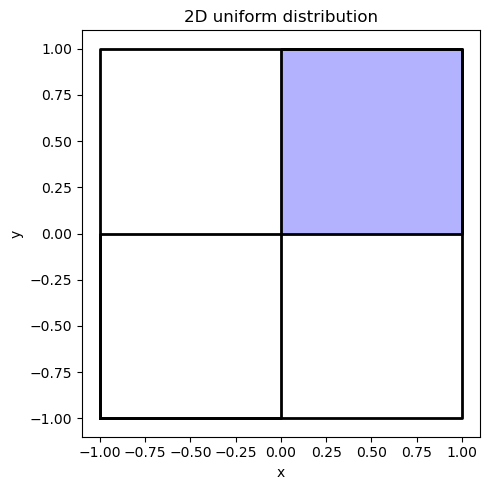

In [22]:
#Square with 4 quadrants

square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]
square1_x = [-1,  0,  0, -1, -1]
square1_y = [-1, -1,  0,  0, -1]
square2_x = [0,  1,  1, 0, 0]
square2_y = [0, 0,  1,  1, 0]

plt.figure(figsize=(5, 5))
plt.plot(square_x, square_y, linewidth=2, label="Square", color='black')
plt.plot(square1_x, square1_y, linewidth=2, label="Square", color='black')
plt.plot(square2_x, square2_y, linewidth=2, label="Square", color='black')
plt.fill(square2_x, square2_y, color="blue", alpha=0.3)
plt.title("2D uniform distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [23]:
#Your answer here

**Q4**: Let's test your answer! Write a code snippet that counts how many of your $N=10000$ dards fell on the upper right quadrant and plot the results

In [25]:
#Your answer here

This example is the basis of Monte Carlo simulations, in which repeated random samples are produced to solve a deterministic problem. Monte Carlo methods have diverse applications ranging from the generation of pseudo-random numbers to uncertainty propagation. 


Following up on the previous task, we will now use a Monte Carlo method to estimate the irrational number $\pi$ . 

Consider the area of the square dardboard above, with side $l = 2$: 

$A_s = l · l = 4$

We can embed inside it a circle of radius $R = 1$, and area: 

$A_c = \pi R^{2} = \pi$

The fraction of points lying inside the circle will be equal to the ratio between the two areas:

$f = A_c/A_s = \pi /4 $

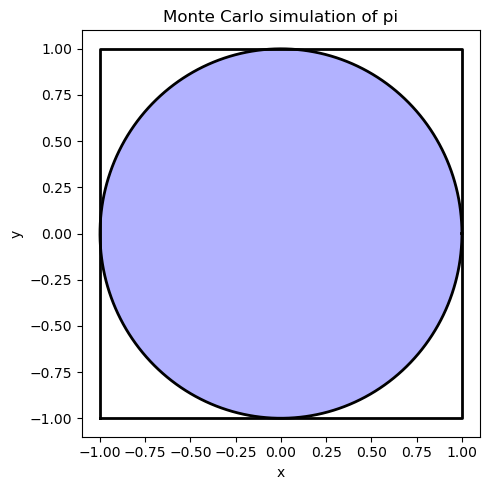

In [26]:
#square with circle
theta = np.linspace(0, 2*np.pi, 400)
square_x = [-1,  1,  1, -1, -1]
square_y = [-1, -1,  1,  1, -1]

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, color='black')
plt.fill(np.cos(theta), np.sin(theta), color="blue", alpha=0.3)
plt.plot(square_x, square_y, linewidth=2, label="Square", color='black')
plt.title("Monte Carlo simulation of pi")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

**Q5**: Write down another function that filters the points falling inside the circle

In [27]:
#Your answer here

**Q6**: Run your function on the $(x, y)$ points generated earlier and plot the results

In [28]:
#Your answer here

**Q7**: What is the corresponding estimate for $\pi$?

In [29]:
#Your answer here